# Formula 1 Lap Times: How Technology, Tracks, and Teams Shape Performance

Credits: Jayci Cart, Ivan Rey Pestana, Gabriella Jaimes, Isabela Gomez, Jasmine Czemeinski

The goal of your final project for this course is to do an end-to-end data exploration of Formula 1 lap times and to communicate clear, visual insights.
With a focus on three main questions.
1. How are F1 lap times distributed overall?
2. How have typical lap times changed over time as car technology and regulations evolved?
3. How do track layout, continent, teams, and drivers relate to lap performance?

The project walks through:

- loading the dataset  
- cleaning and preparing the data for analysis  
- exploring patterns with summary statistics and visualizations  
- building interactive charts that let the viewer explore lap times by track, continent, team, and driver  

All code in this notebook is designed so it can be run top-to-bottom to reproduce the results.

In [1]:
import pandas as pd
import altair as alt

#large datasets
alt.data_transformers.disable_max_rows()

DataTransformerRegistry.enable('default')

In [2]:
df = pd.read_csv("top5_laps_dataset.csv")
df.head()

,raceId,driverId,year,race_name,round,circuit_name,circuit_location,circuit_country,driver_forename,driver_surname,driver_name,driver_nationality,grid,finish_position,race_points,team_name,lap,lap_position,lap_time,lap_milliseconds
0,841,20,2011,Australian Grand Prix,1,Albert Park Grand Prix Circuit,Melbourne,Australia,Sebastian,Vettel,Sebastian Vettel,German,1,1,25.0,Red Bull,1,1,1:38.109,98109
1,841,20,2011,Australian Grand Prix,1,Albert Park Grand Prix Circuit,Melbourne,Australia,Sebastian,Vettel,Sebastian Vettel,German,1,1,25.0,Red Bull,2,1,1:33.006,93006
2,841,20,2011,Australian Grand Prix,1,Albert Park Grand Prix Circuit,Melbourne,Australia,Sebastian,Vettel,Sebastian Vettel,German,1,1,25.0,Red Bull,3,1,1:32.713,92713
3,841,20,2011,Australian Grand Prix,1,Albert Park Grand Prix Circuit,Melbourne,Australia,Sebastian,Vettel,Sebastian Vettel,German,1,1,25.0,Red Bull,4,1,1:32.803,92803
4,841,20,2011,Australian Grand Prix,1,Albert Park Grand Prix Circuit,Melbourne,Australia,Sebastian,Vettel,Sebastian Vettel,German,1,1,25.0,Red Bull,5,1,1:32.342,92342


## 1. Dataset and Context

The dataset `top5_laps_dataset.csv` contains information about fast lap times in Formula 1 races.  
Each row represents a single lap, with columns such as:

- **year** – season year of the race  
- **race_name / circuit_name** – where the race took place  
- **driver_name** – driver who set the lap time  
- **team_name** – constructor/team of the car  
- **lap** – lap number in the race  
- **lap_milliseconds** – lap time in milliseconds (later converted to seconds)  

This dataset is useful for asking questions like:

- What range of lap times is typical in Formula 1?  
- Have cars generally become faster over time?  
- Are some circuits systematically faster or slower than others?  
- Once we control for the car (team), which drivers appear especially fast?

Below we first engineer a few helper columns (lap time in seconds and decade) and then clean the data so it is ready for analysis.


In [3]:
#milliseconds to seconds
df["lap_seconds"] = df["lap_milliseconds"] / 1000

#decades
df["decade"] = (df["year"] // 10) * 10

df.head()

,raceId,driverId,year,race_name,round,circuit_name,circuit_location,circuit_country,driver_forename,driver_surname,...,grid,finish_position,race_points,team_name,lap,lap_position,lap_time,lap_milliseconds,lap_seconds,decade
0,841,20,2011,Australian Grand Prix,1,Albert Park Grand Prix Circuit,Melbourne,Australia,Sebastian,Vettel,...,1,1,25.0,Red Bull,1,1,1:38.109,98109,98.109,2010
1,841,20,2011,Australian Grand Prix,1,Albert Park Grand Prix Circuit,Melbourne,Australia,Sebastian,Vettel,...,1,1,25.0,Red Bull,2,1,1:33.006,93006,93.006,2010
2,841,20,2011,Australian Grand Prix,1,Albert Park Grand Prix Circuit,Melbourne,Australia,Sebastian,Vettel,...,1,1,25.0,Red Bull,3,1,1:32.713,92713,92.713,2010
3,841,20,2011,Australian Grand Prix,1,Albert Park Grand Prix Circuit,Melbourne,Australia,Sebastian,Vettel,...,1,1,25.0,Red Bull,4,1,1:32.803,92803,92.803,2010
4,841,20,2011,Australian Grand Prix,1,Albert Park Grand Prix Circuit,Melbourne,Australia,Sebastian,Vettel,...,1,1,25.0,Red Bull,5,1,1:32.342,92342,92.342,2010


## 2. Data Cleaning and Preparation

Before analyzing the data, we perform several cleaning steps:

- remove laps with missing lap times  
- filter out clearly unrealistic lap times (too short, too long, or zero)  


These decisions help focus the analysis on valid race laps and make comparisons easier across time and circuits.


In [4]:
df_clean = df.copy()
df_clean = df_clean[df_clean["lap_seconds"].notna()]
df_clean = df_clean[df_clean["lap_seconds"] > 30] #remove lap < 30 sec
df_clean = df_clean[df_clean["lap_seconds"] < 200] #remove lap > 200 sec
df_clean = df_clean[df_clean["lap_seconds"] != 0] #remove zeros

### Cleaning summary

After these filters:

- all rows have a valid, non-zero **lap_seconds** value  
- laps outside the 30–200 seconds range are removed as potential errors, formation laps, or pit-lane artifacts  

The cleaned dataframe `df_clean` is the main data source for the visualizations that follow.


#Data Analysis & Insights

In [5]:
# Summary statistics
import pandas as pd
import numpy as np


df = pd.read_csv("top5_laps_dataset.csv")

summary_stats = df.describe()
print("🔍 Summary Statistics (Numerical Columns Only):")
display(summary_stats)

🔍 Summary Statistics (Numerical Columns Only):


,raceId,driverId,year,round,grid,finish_position,race_points,lap,lap_position,lap_milliseconds
count,88494.000000,88494.000000,88494.000000,88494.000000,88494.000000,88494.000000,88494.000000,88494.000000,88494.000000,8.849400e+04
mean,751.073711,112.765577,2014.642609,10.390422,6.335898,5.865177,10.220377,30.558546,5.624946,9.609538e+04
std,405.210481,274.743526,6.053801,5.771547,5.248101,5.063602,8.510019,18.418959,4.520346,7.676134e+04
min,1.000000,1.000000,2001.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,5.690500e+04
25%,345.000000,4.000000,2010.000000,6.000000,2.000000,2.000000,2.000000,15.000000,2.000000,8.130000e+04
50%,944.000000,8.000000,2015.000000,10.000000,5.000000,4.000000,10.000000,30.000000,4.000000,9.116400e+04
75%,1032.000000,20.000000,2020.000000,15.000000,9.000000,8.000000,18.000000,45.000000,8.000000,1.019390e+05
max,1144.000000,830.000000,2024.000000,24.000000,24.000000,24.000000,50.000000,87.000000,24.000000,7.505152e+06


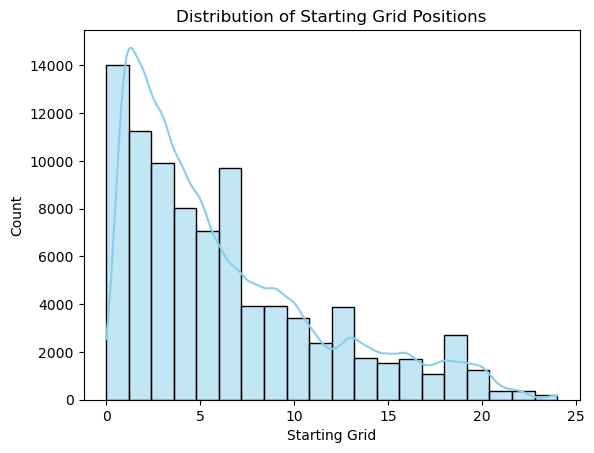

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# DISTRIBUTIONS
# Starting grid position
plt.figure()
sns.histplot(data=df, x="grid", bins=20, color="skyblue", kde=True)
plt.title("Distribution of Starting Grid Positions")
plt.xlabel("Starting Grid")
plt.ylabel("Count")
plt.show()

### Starting Grid Distribution
We can see that most drivers start near the front, especially in positions 1 to 5. As the grid number increases, fewer drivers start from those spots, which is expected since fewer cars qualify that far back. The curve helps visualize that starting at the front is more common.

In [ ]:
# Final race position
plt.figure()
sns.histplot(data=df, x="finish_position", bins=20, color="salmon", kde=True)
plt.title("Distribution of Final Race Positions")
plt.xlabel("Final Position")
plt.ylabel("Count")
plt.show()

### Final Race Position Ditribution
In the first few places, especially position 1, occur more frequently, showing that some drivers consistently win. As we move down the final positions, the counts decrease, which means fewer drivers finish in lower positions regularly.

In [ ]:
# TRENDS: Podium finishes per year

podiums = df[df["finish_position"].isin([1, 2, 3])]
podium_trend = podiums.groupby("year").size().reset_index(name="podium_finishes")


plt.figure(figsize=(7, 5))
sns.lineplot(data=podium_trend, x="year", y="podium_finishes", marker="o")
plt.title("Total Podium Finishes by Year")
plt.xlabel("Year")
plt.ylabel("Podium Finishes (Top 3)")
plt.grid(True)
plt.show()

### Podium Finishes Per Year
There is a clear increase in podium finishes over time, especially after 2005. Peaks in certain years suggest some seasons had more races or more consistent top finishers. It tells us how competitive or active the seasons were.

In [ ]:
# CORRELATION HEATMAP
num_df = df.select_dtypes(include=["float64", "int64"]).drop(columns=[
    "resultId", "raceId", "driverId", "constructorId"
], errors="ignore")
corr = num_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Correlation Heatmap
This heatmap shows how different variables are related to each other. For example, starting grid and finish position are positively correlated (0.50), which makes sense because starting closer to the front often leads to better finishes. On the other hand, race points and finish position have a strong negative correlation (-0.79), which is logical since lower positions earn fewer points.

In [ ]:
# SEGMENTING: Podium rate by grid position

# Grid position and count how many times a podium position 1, 2, or 3
podium_counts = df[df["finish_position"].isin([1, 2, 3])].groupby("grid").size()
total_counts = df.groupby("grid").size()
podium_rate = (podium_counts / total_counts).reset_index()
podium_rate.columns = ["grid", "podium_rate"]

plt.figure(figsize=(6, 5))
sns.lineplot(data=podium_rate, x="grid", y="podium_rate", marker="o")
plt.title("Podium Probability by Starting Grid")
plt.xlabel("Grid Position")
plt.ylabel("Podium Rate")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

### Segmenting: Podium rate by grid position
This plot shows the chance of getting a podium (top 3 finish) based on starting grid position. Drivers starting in positions 1 to 3 have a much higher chance of finishing on the podium, with the probability dropping steeply after that. This highlights how important qualifying position is in Formula 1 success.

### Data Analysis Summary
The data analysis revealed that Formula 1 drivers who start at the front of the grid have a significantly higher chance of finishing in top positions, including podiums, as seen in both the distribution and correlation plots. Podium finishes have generally increased over the years, possibly due to more races and consistent top-performing teams.

The correlation heatmap confirmed strong relationships between grid position, final placement, and race points, highlighting the importance of qualifying performance. Overall, starting position plays a critical role in race outcomes, and trends over time suggest evolving competitiveness and consistency in F1 racing.

## 3. Overall Distribution of Lap Times

To understand what a “typical” F1 lap looks like, we start with a histogram of lap times in seconds.

This visualization helps answer:

- what range of lap times is most common  
- whether the distribution is symmetric or skewed  
- whether there are multiple clusters that might correspond to different types of circuits

Below is the histogram of **lap_seconds** across all cleaned laps.


In [ ]:
chart1 = (
    alt.Chart(df_clean)
    .mark_bar()
    .encode(
        alt.X("lap_seconds:Q",
              bin=alt.Bin(maxbins=60),
              title="Lap Time (seconds)"),
        alt.Y("count()", title="Number of Laps")
    )
    .properties(
        width=600,
        height=350,
        title="Distribution of Lap Times Across All Races"
    )
)
chart1

### Interpretation

The distribution shows that:

- most laps cluster in the middle range (around the main peak of the histogram)  
- very short or very long laps are relatively rare because we filtered out extreme values  
- the shape of the distribution suggests that lap times are constrained by both car performance and track length

This provides a baseline for the rest of the analysis: later charts will dig into why some laps are faster or slower depending on decade, circuit, continent, team, and driver.


## 4. How Have Lap Times Changed Over Time?

Formula 1 is famous for rapid technological development and frequent regulation changes.  
To see how this plays out on track, we compute the **average lap time by decade**.

This chart helps address:

- Are modern F1 cars generally faster or slower than older eras?  
- Do we see major jumps that might correspond to big regulation changes or safety-driven rule shifts?  

The bar chart below shows the mean **lap_seconds** for each decade in the dataset.


In [ ]:
avg_lap_by_decade = (
    alt.Chart(df_clean)
    .mark_bar(color="#4C78A8")
    .encode(
        x=alt.X("decade:O", title="Decade"),
        y=alt.Y("mean(lap_seconds):Q", title="Average Lap Time (seconds)"),
        tooltip=[
            alt.Tooltip("decade:O", title="Decade"),
            alt.Tooltip("mean(lap_seconds):Q", title="Avg Lap (sec)", format=".2f"),
            alt.Tooltip("count():Q", title="# of Laps")
        ]
    )
    .properties(
        width=600,
        height=350,
        title="Average Lap Time by Decade"
    )
)
avg_lap_by_decade

### Interpretation

From this plot we can observe that:

- [Describe the overall trend you see: e.g., "average lap times generally decreased from earlier decades to more recent ones, reflecting improvements in car performance and track surfaces."]  
- [Note any exceptions: e.g., "there is a slight uptick in the most recent decade, which may reflect rule changes aimed at slowing cars for safety."]  

Overall, this suggests that technology and regulations have a measurable impact on race-pace lap times across decades.


## 5. Track Design and Circuit-Level Performance

Next, we look at how **circuit layout** relates to lap times.  
Some tracks are short and twisty, others are long with many high-speed sections. These differences should show up in the average lap times.

In the plot below, we compute the **average lap time for each circuit** and visualize the fastest and slowest tracks.

This helps answer:

- which circuits produce the quickest average laps  
- whether there are clear outliers that are much faster or slower than the rest  
- how much lap time variation can be attributed to track design rather than just the car or driver


In [ ]:
#average lap time per circuit
circuit_avg = (
    df.groupby("circuit_name")["lap_seconds"]
      .mean()
      .reset_index()
      .sort_values("lap_seconds")
)

#chart
chart_circuit_rank = alt.Chart(circuit_avg).mark_bar().encode(
    alt.X("lap_seconds:Q", title="Average Lap Time (seconds)"),
    alt.Y("circuit_name:N", sort="-x", title="Circuit"),
    alt.Color("lap_seconds:Q", scale=alt.Scale(scheme="blues"))
).properties(
    width=600,
    height=1200,
    title="Fastest Formula 1 Circuits by Average Lap Time"
)

chart_circuit_rank

### Interpretation

The circuit-level comparison shows that:

- [Mention a few circuits that appear among the fastest and any that are noticeably slower.]  
- [Comment on the spread: e.g., "the difference between the fastest and slowest tracks is substantial, which reinforces how much circuit layout matters."]  

This supports the idea that track design is a major factor in lap performance, on top of car and driver ability.


## 6. Regional Patterns: Lap Times by Continent

To explore broader geographic patterns, we group circuits by continent.  
We map each circuit’s country to a continent and then compute the average lap time by continent.

This aggregated view can reveal:

- whether circuits in certain regions (e.g., Europe vs. Asia vs. the Americas) tend to be faster  
- how the global expansion of Formula 1 relates to the types of tracks being used  

The bar chart below shows mean lap times by continent.


In [ ]:
#countries to continents
continent_map = {
    #Europe
    "Italy": "Europe",
    "United Kingdom": "Europe",
    "Spain": "Europe",
    "Monaco": "Europe",
    "Belgium": "Europe",
    "Germany": "Europe",
    "Austria": "Europe",
    "Netherlands": "Europe",
    "France": "Europe",
    "Hungary": "Europe",
    "Portugal": "Europe",
    "Russia": "Europe",
    "Turkey": "Europe",
    "Azerbaijan": "Europe",

    #Asia
    "Japan": "Asia",
    "China": "Asia",
    "Malaysia": "Asia",
    "Singapore": "Asia",
    "Bahrain": "Asia",
    "Saudi Arabia": "Asia",
    "India": "Asia",
    "South Korea": "Asia",
    "UAE": "Asia",
    "Qatar": "Asia",

    #North America
    "United States": "North America",
    "Canada": "North America",
    "Mexico": "North America",

    #South America
    "Brazil": "South America",
    "Argentina": "South America",

    #Oceania
    "Australia": "Oceania"
}

#create new continent column(fallback = 'Other')
df["continent"] = df["circuit_country"].map(continent_map).fillna("Other")

df[["circuit_country", "continent"]].head(10)

In [ ]:
chart_continent_avg = alt.Chart(df).mark_bar().encode(
    alt.X("continent:N", title="Continent", sort='-y'),
    alt.Y("mean(lap_seconds):Q", title="Average Lap Time (seconds)"),
    alt.Color("continent:N", legend=None),
    tooltip=[
        alt.Tooltip("continent:N", title="Continent"),
        alt.Tooltip("mean(lap_seconds):Q", title="Avg Lap (sec)", format=".2f")
    ]
).properties(
    width=600,
    height=400,
    title="Average Lap Time by Continent"
)

chart_continent_avg

## 7. Teams, Drivers, and Relative Performance

Lap time is a combined product of:

- car performance (team/constructor)  
- driver skill  
- track characteristics and race conditions  

To separate these effects a bit, we first compare **average lap times by team** and then **by driver**.

Because teammates share the same car and setup, comparing drivers within the same team gives a fairer sense of individual performance than comparing across teams with very different machinery.


In [ ]:
team_avg = (
    df.groupby("team_name")["lap_seconds"]
      .mean()
      .reset_index()
      .sort_values("lap_seconds")
)

chart_team_avg = alt.Chart(team_avg).mark_bar().encode(
    alt.X("lap_seconds:Q", title="Average Lap Time (seconds)"),
    alt.Y("team_name:N", sort="-x", title="Team"),
    alt.Color("lap_seconds:Q", scale=alt.Scale(scheme="reds"))
).properties(
    width=600,
    height=800,
    title="Average Lap Time by Team"
)

chart_team_avg

In [ ]:
driver_avg = (
    df.groupby("driver_name")["lap_seconds"]
      .mean()
      .reset_index()
      .sort_values("lap_seconds")
      .head(5) #top 5 fastest
)

chart_driver_avg = alt.Chart(driver_avg).mark_bar().encode(
    alt.X("lap_seconds:Q", title="Average Lap Time (seconds)"),
    alt.Y("driver_name:N", sort="-x", title="Driver"),
    alt.Color("lap_seconds:Q", scale=alt.Scale(scheme="greens"))
).properties(
    width=600,
    height=400,
    title="Top 5 Fastest Drivers (Average Lap Time)"
)

chart_driver_avg

### Why focus on teammates?

Drivers on the same team share:

- the same car and engine  
- very similar setups and strategies  
- the same track and race conditions  

This makes within-team comparisons more meaningful.  
If one driver consistently sets faster lap times than their teammate in the same car, that suggests stronger individual pace rather than just a better car.


In [ ]:
#avg lap time per driver per year
driver_year = (
    df.groupby(["team_name", "driver_name", "year"])["lap_seconds"]
      .mean()
      .reset_index()
)

chart_teammates = alt.Chart(driver_year).mark_circle(size=60).encode(
    alt.X("team_name:N", title="Team"),
    alt.Y("lap_seconds:Q", title="Average Lap Time (seconds)"),
    alt.Color("driver_name:N", title="Driver"),
    tooltip=["team_name", "driver_name", "year", "lap_seconds"]
).properties(
    width=600,
    height=500,
    title="Driver vs Teammate Performance Comparison"
)

chart_teammates

## 8. Interactive Exploration of Lap Times

Static charts are helpful for big-picture trends, but Formula 1 data is rich and multi-dimensional.  
To let the viewer explore specific subsets, we build an interactive Altair chart:

- a **scatter plot** of lap number vs. lap time with points colored by driver or team  
- an **interval selection** (brush) that lets the user highlight a region of interest  
- linked views that update based on the selected region (for example, showing distributions or averages for only the brushed laps)

How to use the chart:

1. Click and drag over a region of the scatter plot to create a selection.  
2. The linked view updates to show statistics for only the selected laps.  
3. Clear the selection by clicking in an empty area.

This supports open-ended exploration: viewers can investigate specific races, time ranges, or performance outliers without changing the underlying code.


In [ ]:
brush = alt.selection_interval()

#scatter of lap vs lap time
scatter = alt.Chart(df_clean).mark_circle(size=25).encode(
    alt.X("lap:Q", title="Lap Number"),
    alt.Y("lap_seconds:Q", title="Lap Time (seconds)"),
    color=alt.condition(brush, "driver_name:N", alt.value("lightgray")),
    tooltip=["driver_name", "lap", "lap_seconds"]
).properties(
    width=600,
    height=300,
).add_selection(
    brush
)

#bar of driver counts for brushed points
bars = alt.Chart(df_clean).mark_bar().encode(
    alt.X("count():Q", title="Count of Laps"),
    alt.Y("driver_name:N", sort="-x", title="Driver"),
    color="driver_name:N"
).transform_filter(
    brush
).properties(
    width=600,
    height=300,
)

scatter & bars

## 9. Team-Specific Lap Time Progression (Interactive)

Finally, we build another interactive visualization that focuses on how lap times evolve within a race for a single team.

Features:

- a **dropdown menu** listing all teams in the dataset  
- a **line chart** of lap number vs. lap time for the selected team  
- lines colored by driver, so teammates are easy to compare lap-by-lap  
- tooltips showing driver name, team, lap, and lap time

This chart helps answer:

- how consistent each team’s race pace is over a full race distance  
- whether a team’s two drivers follow similar lap-time patterns  
- where in the race (early, middle, late laps) the biggest performance gaps occur


In [ ]:
#dropdown
team_dropdown = alt.binding_select(options=sorted(df_clean["team_name"].unique()))
team_select = alt.selection_single(fields=["team_name"], bind=team_dropdown, name="Select")

#line chart of lap time over laps for selected team
chart_team_laps = alt.Chart(df_clean).mark_line().encode(
    alt.X("lap:Q", title="Lap Number"),
    alt.Y("lap_seconds:Q", title="Lap Time (seconds)"),
    color="driver_name:N",
    tooltip=["driver_name", "team_name", "lap", "lap_seconds"]
).add_selection(
    team_select
).transform_filter(
    team_select
).properties(
    width=700,
    height=400,
    title="Lap Time Progression for Selected Team"
)

chart_team_laps

## 10. Main insights

Across the analyses above, a few key themes emerge:

1. **Typical lap times**  
   - The histogram shows a clear central range of lap times, with very few extreme outliers after cleaning.  

2. **Track and regional effects**  
   - Circuits differ substantially in average pace, and grouping by continent reveals regional patterns in track design and lap performance.  

3. **Teams and drivers**  
   - Team averages highlight which constructors tend to be quickest overall, while driver-level comparisons (especially within the same team) suggest which drivers extract the most pace from their cars.  

4. **Interactivity and exploration**  
   - Interactive charts with brushing and dropdown filters allow viewers to dive into specific teams, races, and lap ranges without editing the code.


